# 1. Data preparation


In [7]:
# Mounting gdrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset from Google Drive into a pandas DataFrame
df = pd.read_csv("/content/drive/MyDrive/#17. Project sama Dzaka dan Agung/Skripsi IndoBERT/PRDECT-ID Dataset (1).csv")
df.head() # display 5 rows

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


# 2. The distribution of price and sales

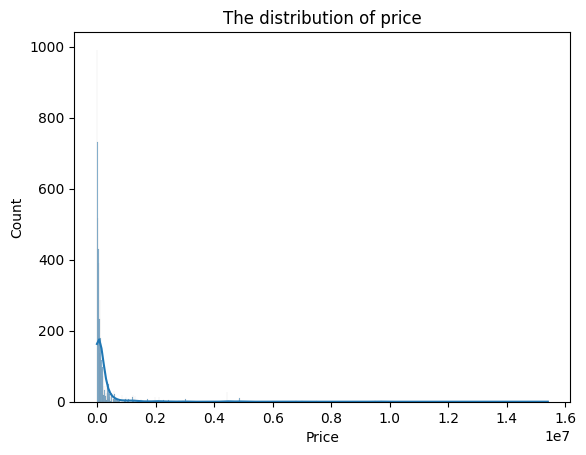

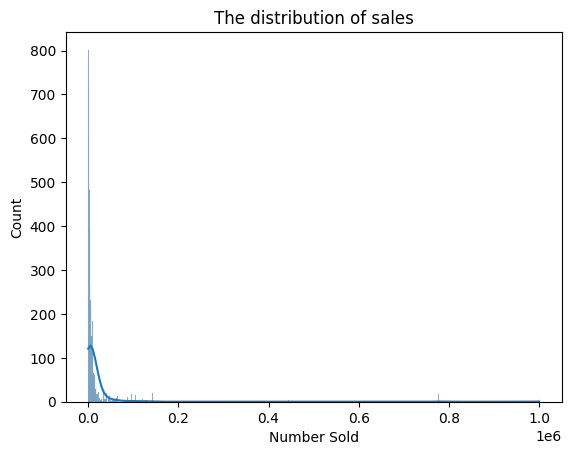

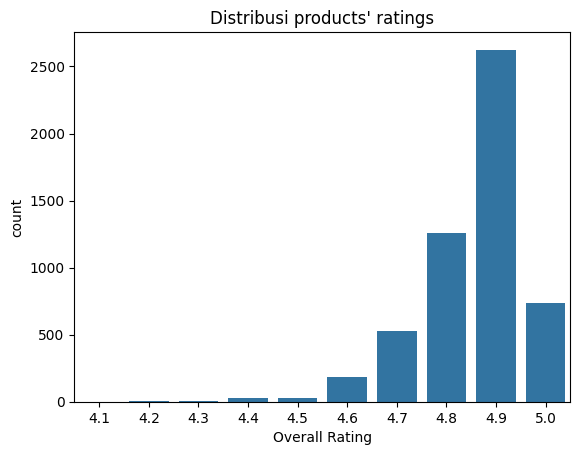

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], kde=True)
plt.title("The distribution of price")
plt.show()

sns.histplot(df['Number Sold'], kde=True)
plt.title("The distribution of sales")
plt.show()

sns.countplot(x='Overall Rating', data=df)
plt.title("Distribusi products' ratings")
plt.show()




# 3. The sales based on the categories

In [9]:
# aggregating the number sold and overall rating based on categories
df.groupby('Category')[['Number Sold','Overall Rating']].mean()


,Number Sold,Overall Rating
Category,,
Animal Care,20920.090,4.90100
Automotive,19121.375,4.83250
Beauty,6518.980,4.87850
Body Care,25640.415,4.91350
Books,3553.875,4.90500
Camera,4984.565,4.79150
Carpentry,16565.375,4.82400
Computers and Laptops,6436.930,4.86800
Electronics,6118.710,4.84250


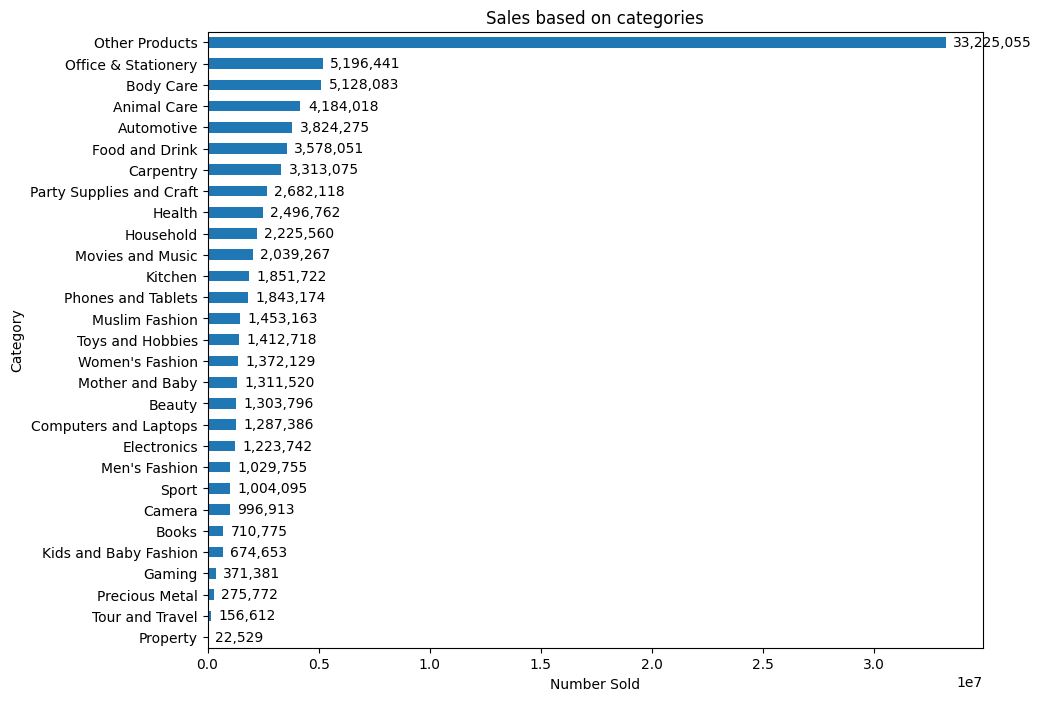

In [12]:
cat_sales = (
    df.groupby('Category')['Number Sold']
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))
ax = cat_sales.plot(kind='barh')

# add label
for i, v in enumerate(cat_sales):
    ax.text(
        v + max(cat_sales)*0.01,
        i,
        f"{v:,}",
        va='center'
    )

plt.title("Sales based on categories")
plt.xlabel("Number Sold")

plt.show()


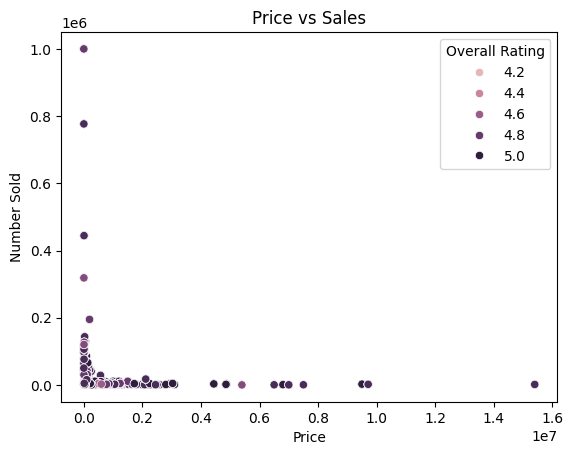

In [13]:
sns.scatterplot(
    x='Price',
    y='Number Sold',
    hue='Overall Rating',
    data=df
)
plt.title("Price vs Sales")
plt.show()


#4. The distribution of sentiments

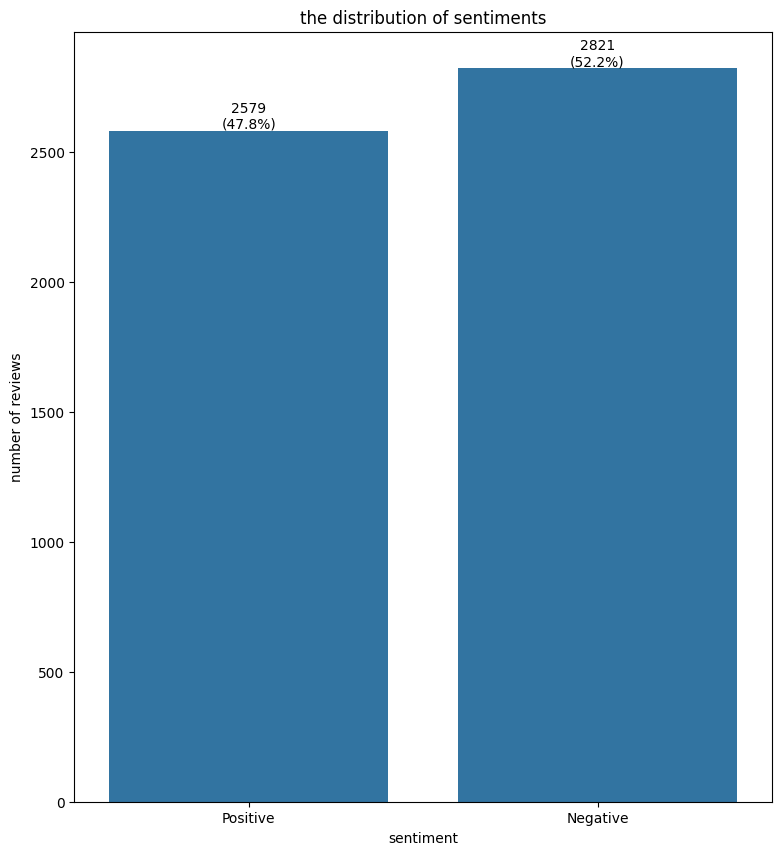

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# hitung distribusi
counts = df['Sentiment'].value_counts()
total = len(df)

plt.figure(figsize=(9,10))
ax = sns.countplot(x='Sentiment', data=df)

# tambah label di atas bar
for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total

    ax.annotate(
        f'{count}\n({percent:.1f}%)',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("the distribution of sentiments")
plt.xlabel("sentiment")
plt.ylabel("number of reviews")
plt.show()



#5. Wordcloud


In [15]:
! pip install wordcloud nltk


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


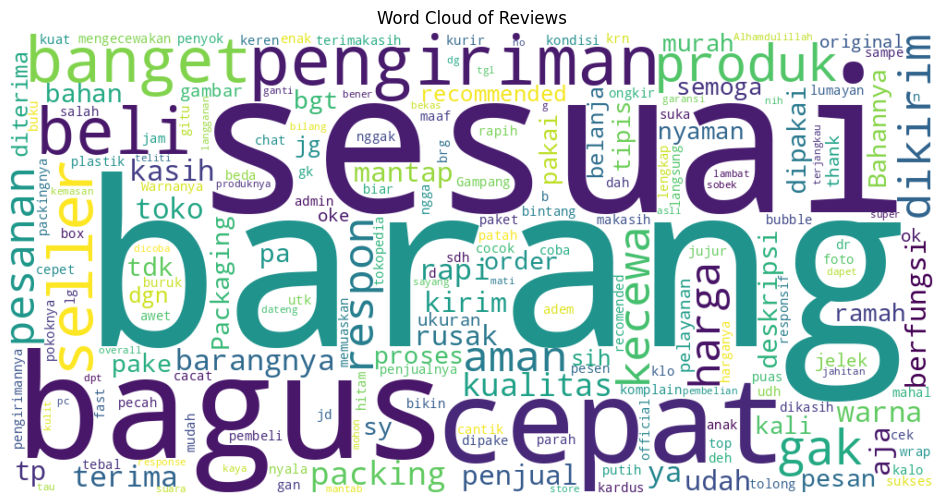

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# download stopwords
nltk.download('stopwords')

# appending all reviews
text = " ".join(df['Customer Review'].astype(str))

# stopwords Indonesia + custom
stop_words = set(stopwords.words('indonesian'))
custom_stopwords = {
    'dan','yang','di','ke','dari','nya','untuk',
    'saya','ini','itu','dengan','karena','yg', 'ga'
}
stop_words.update(custom_stopwords)

# creating word cloud
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stop_words,
    collocations=False
).generate(text)

# displaying
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()
